# Dự Báo Giá Nhà (House Price Prediction)

Hệ thống thông minh dự đoán giá nhà tại Việt Nam.
Bài toán học có giám sát dạng hồi quy, dự đoán Price từ thông tin bất động sản.

Thực hiện các bước:
1. Load data và biểu diễn dữ liệu
2. Phân tích đặc trưng và biến mục tiêu
3. Phân tích khám phá dữ liệu (EDA)
4. Chia tập huấn luyện/kiểm tra
5. Baseline
6. Xây dựng 4 mô hình hồi quy
7. Đánh giá và so sánh
8. Khảo sát hyperparameter
9. Khảo sát feature
10. Mô hình cuối cùng
11. Triển khai ứng dụng


## 5. Data Representation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


### 5.1. Kiểm tra dữ liệu sau khi đọc


In [2]:
# Đọc dữ liệu
df = pd.read_csv('house_prices.csv')
df_raw = df.copy()

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB


### 5.2. Kiểm tra chất lượng dữ liệu: Null và giá trị 0


In [4]:
# Kiểm tra tỷ lệ null
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_report = pd.DataFrame({
    'Số lượng null': df.isnull().sum().sort_values(ascending=False),
    'Tỷ lệ thiếu (%)': null_pct
})
display(null_report[null_report['Số lượng null'] > 0])


,Số lượng null,Tỷ lệ thiếu (%)
Balcony direction,24983,82.645804
House direction,21239,70.260346
Furniture state,14119,46.706805
Access Road,13297,43.987562
Frontage,11564,38.254656
Bathrooms,7074,23.401370
Bedrooms,5162,17.076317
Legal status,4506,14.906216
Floors,3603,11.919018


## 6. Feature and Target Analysis


In [5]:
# Thống kê mô tả cho các cột số
num_cols_all = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Price']
for col in num_cols_all:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

display(df[num_cols_all].describe().T)


,count,mean,std,min,25%,50%,75%,max
Area,30229.0,68.498741,48.069835,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,5.361692,4.346174,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,7.853800,7.451313,1.0,4.0,6.0,10.0,85.0
Floors,26626.0,3.410426,1.328897,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,3.511030,1.309116,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,3.346837,1.400181,1.0,2.0,3.0,4.0,9.0
Price,30229.0,5.872078,2.211877,1.0,4.2,5.9,7.5,11.5


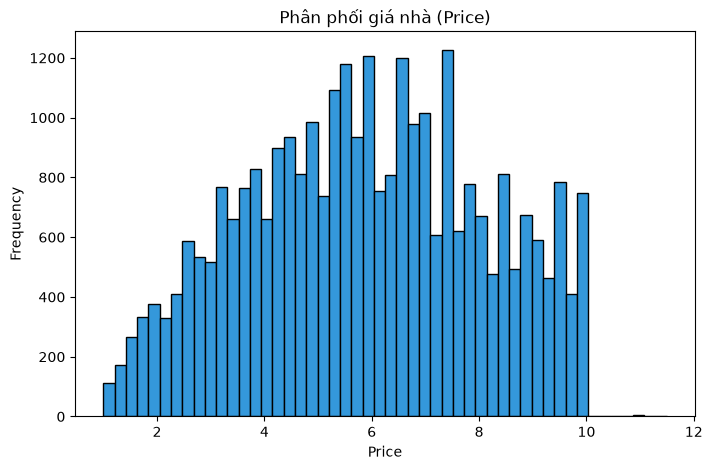

Price - Mean: 5.87, Median: 5.90
Price - Min: 1.00, Max: 11.50


In [6]:
# Phân phối biến mục tiêu Price
plt.figure(figsize=(8, 5))
plt.hist(df['Price'].dropna(), bins=50, edgecolor='black', color='#3498db')
plt.title('Phân phối giá nhà (Price)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

print(f"Price - Mean: {df['Price'].mean():.2f}, Median: {df['Price'].median():.2f}")
print(f"Price - Min: {df['Price'].min():.2f}, Max: {df['Price'].max():.2f}")


## 7. Exploratory Data Analysis


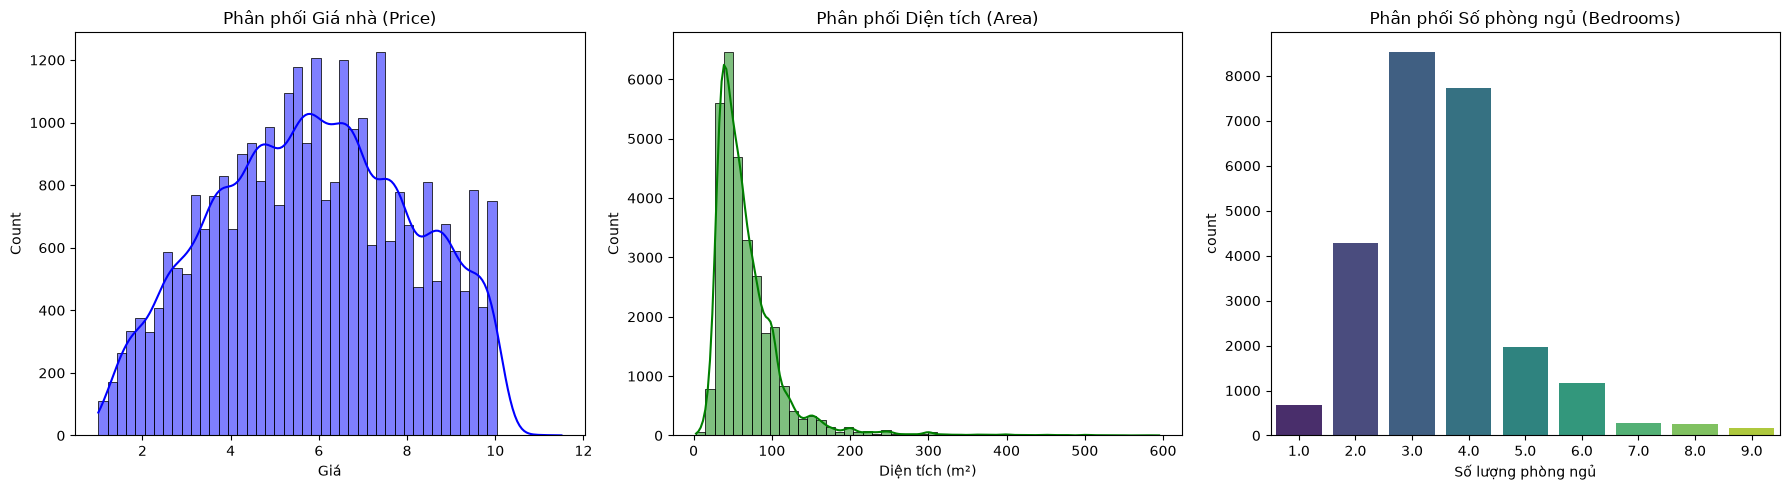

In [7]:
# 3 biểu đồ phân phối
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ 1: Phân phối Giá nhà
sns.histplot(df['Price'].dropna(), bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối Giá nhà (Price)')
axes[0].set_xlabel('Giá')

# Biểu đồ 2: Phân phối Diện tích
sns.histplot(df['Area'].dropna(), bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Phân phối Diện tích (Area)')
axes[1].set_xlabel('Diện tích (m²)')

# Biểu đồ 3: Phân phối Số phòng ngủ
sns.countplot(x='Bedrooms', data=df.dropna(subset=['Bedrooms']), ax=axes[2], palette='viridis')
axes[2].set_title('Phân phối Số phòng ngủ (Bedrooms)')
axes[2].set_xlabel('Số lượng phòng ngủ')

plt.tight_layout()
plt.show()


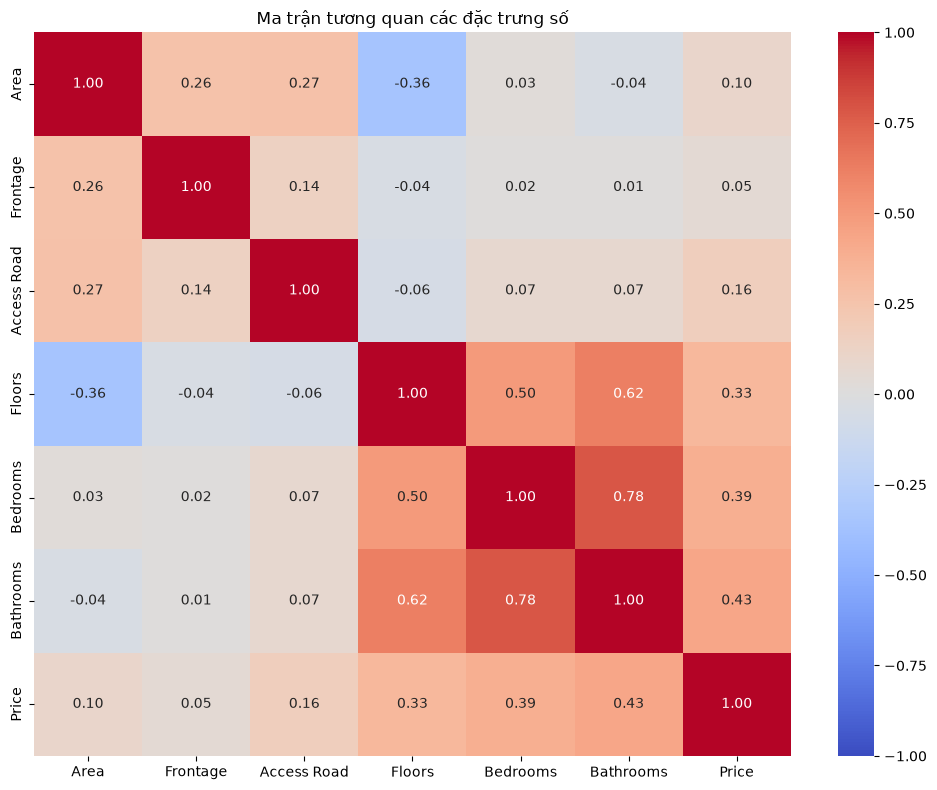


Tương quan với Price:
Price          1.000000
Bathrooms      0.434101
Bedrooms       0.389432
Floors         0.331639
Access Road    0.164280
Area           0.097593
Frontage       0.047469
Name: Price, dtype: float64


In [8]:
# Ma trận tương quan cho các cột số
corr_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Price']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Ma trận tương quan các đặc trưng số")
plt.tight_layout()
plt.show()

print("\nTương quan với Price:")
print(corr_matrix['Price'].sort_values(ascending=False))


Ma trận tương quan cho thấy Bathrooms, Bedrooms và Floors có quan hệ dương rõ nhất với Price.


## 8. Train/Test Split


In [9]:
# Tiền xử lý dữ liệu
df_processed = df.copy()

# Xử lý cột số
num_cols = ['Floors', 'Bedrooms', 'Bathrooms']
for col in num_cols:
    if col in df_processed.columns:
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# Biến mục tiêu
df_processed['Price'] = pd.to_numeric(df_processed['Price'], errors='coerce')
df_processed = df_processed.dropna(subset=['Price'])

# Loại bỏ outlier (quantile 99%)
q = df_processed['Price'].quantile(0.99)
df_processed = df_processed[df_processed['Price'] < q]
print(f"Số mẫu sau khi loại outlier: {len(df_processed)}")

# Chọn feature ban đầu: 3 numeric
NUMERIC_FEATURES = ['Floors', 'Bedrooms', 'Bathrooms']
X = df_processed[NUMERIC_FEATURES].copy()
y = df_processed['Price'].copy()

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Train size: {X_train.shape}; Test size: {X_test.shape}")


Số mẫu sau khi loại outlier: 29743
Train size: (23794, 3); Test size: (5949, 3)


### 8.1. Xử lý giá trị thiếu sau khi chia Train/Test


In [10]:
# Pipeline tiền xử lý cho numeric features
from sklearn.pipeline import make_pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_processed = numeric_pipeline.fit_transform(X_train)
X_test_processed = numeric_pipeline.transform(X_test)
print("Tiền xử lý hoàn tất.")


Tiền xử lý hoàn tất.


## 9. Baseline


In [11]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train_processed, y_train)
baseline_pred = baseline.predict(X_test_processed)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline (Mean) - MAE: {baseline_mae:.3f}, RMSE: {baseline_rmse:.3f}, R²: {baseline_r2:.3f}")


Baseline (Mean) - MAE: 1.814, RMSE: 2.168, R²: -0.001


Baseline luôn dự đoán giá trung bình của tập train. R² = 0 theo định nghĩa. Mọi mô hình phải vượt mốc này.


## 10. Model 1 — Linear Regression


,Train,Test
MAE,1.628758,1.634773
RMSE,1.980886,1.986469
R²,0.162212,0.159731


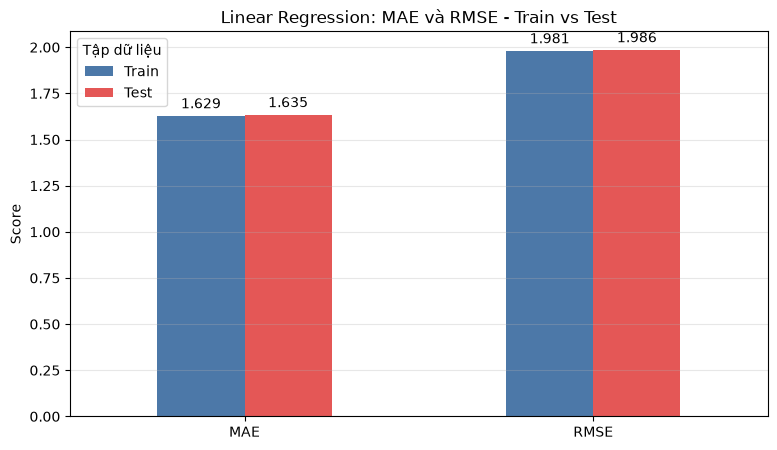

In [12]:
from sklearn.linear_model import LinearRegression

results = []

lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
lr_train_pred = lr_model.predict(X_train_processed)
lr_test_pred = lr_model.predict(X_test_processed)

# Metrics
lr_metrics = pd.DataFrame({
    "Train": [
        mean_absolute_error(y_train, lr_train_pred),
        np.sqrt(mean_squared_error(y_train, lr_train_pred)),
        r2_score(y_train, lr_train_pred)
    ],
    "Test": [
        mean_absolute_error(y_test, lr_test_pred),
        np.sqrt(mean_squared_error(y_test, lr_test_pred)),
        r2_score(y_test, lr_test_pred)
    ]
}, index=["MAE", "RMSE", "R²"])
display(lr_metrics)

results.append({
    'Model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test, lr_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, lr_test_pred)),
    'R²': r2_score(y_test, lr_test_pred)
})

# Biểu đồ Train vs Test
ax = lr_metrics.loc[["MAE", "RMSE"]].plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title("Linear Regression: MAE và RMSE - Train vs Test")
plt.ylabel("Score"); plt.xticks(rotation=0)
plt.legend(title="Tập dữ liệu"); plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()


## 11. Model 2 — Decision Tree Regressor


,Train,Test
MAE,1.562620,1.588724
RMSE,1.922506,1.949015
R²,0.210866,0.191118


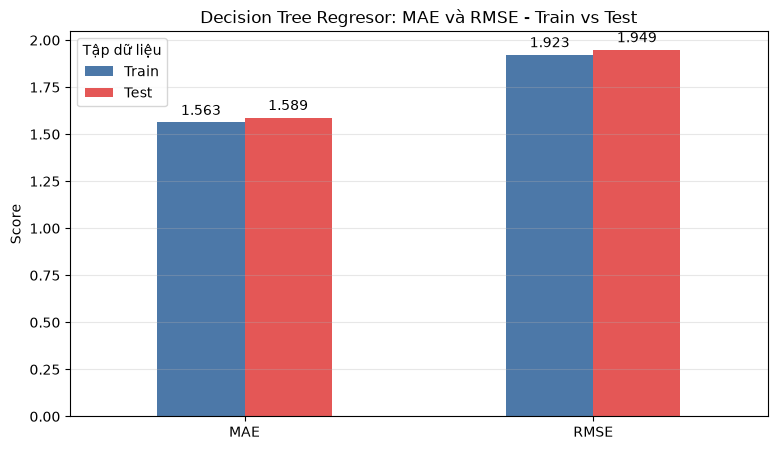

In [13]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_processed, y_train)
dt_train_pred = dt_model.predict(X_train_processed)
dt_test_pred = dt_model.predict(X_test_processed)

dt_metrics = pd.DataFrame({
    "Train": [
        mean_absolute_error(y_train, dt_train_pred),
        np.sqrt(mean_squared_error(y_train, dt_train_pred)),
        r2_score(y_train, dt_train_pred)
    ],
    "Test": [
        mean_absolute_error(y_test, dt_test_pred),
        np.sqrt(mean_squared_error(y_test, dt_test_pred)),
        r2_score(y_test, dt_test_pred)
    ]
}, index=["MAE", "RMSE", "R²"])
display(dt_metrics)

results.append({
    'Model': 'Decision Tree',
    'MAE': mean_absolute_error(y_test, dt_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, dt_test_pred)),
    'R²': r2_score(y_test, dt_test_pred)
})

# Biểu đồ Train vs Test
ax = dt_metrics.loc[["MAE", "RMSE"]].plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title("Decision Tree Regresor: MAE và RMSE - Train vs Test")
plt.ylabel("Score"); plt.xticks(rotation=0)
plt.legend(title="Tập dữ liệu"); plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()


## 12. Model 3 — Random Forest Regressor


,Train,Test
MAE,1.564241,1.587916
RMSE,1.922995,1.945525
R²,0.210465,0.194012


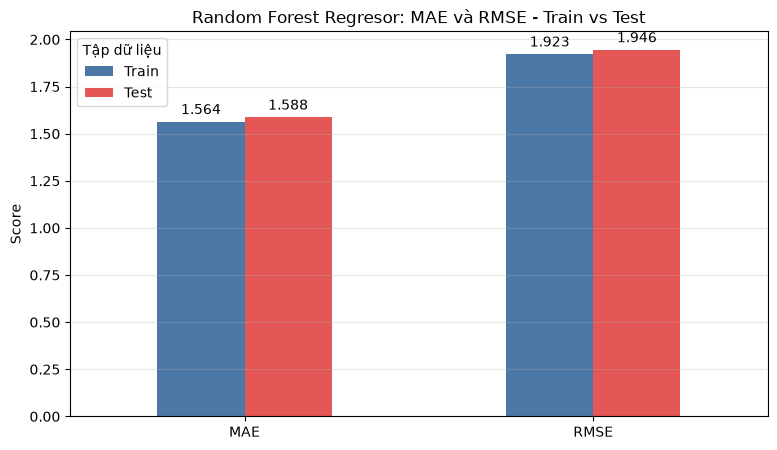

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)
rf_train_pred = rf_model.predict(X_train_processed)
rf_test_pred = rf_model.predict(X_test_processed)

rf_metrics = pd.DataFrame({
    "Train": [
        mean_absolute_error(y_train, rf_train_pred),
        np.sqrt(mean_squared_error(y_train, rf_train_pred)),
        r2_score(y_train, rf_train_pred)
    ],
    "Test": [
        mean_absolute_error(y_test, rf_test_pred),
        np.sqrt(mean_squared_error(y_test, rf_test_pred)),
        r2_score(y_test, rf_test_pred)
    ]
}, index=["MAE", "RMSE", "R²"])
display(rf_metrics)

results.append({
    'Model': 'Random Forest',
    'MAE': mean_absolute_error(y_test, rf_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_test_pred)),
    'R²': r2_score(y_test, rf_test_pred)
})

# Biểu đồ Train vs Test
ax = rf_metrics.loc[["MAE", "RMSE"]].plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title("Random Forest Regresor: MAE và RMSE - Train vs Test")
plt.ylabel("Score"); plt.xticks(rotation=0)
plt.legend(title="Tập dữ liệu"); plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()


## 13. Model 4 — Support Vector Regression (SVR)


,Train,Test
MAE,1.563118,1.579127
RMSE,1.941708,1.955974
R²,0.195024,0.185331


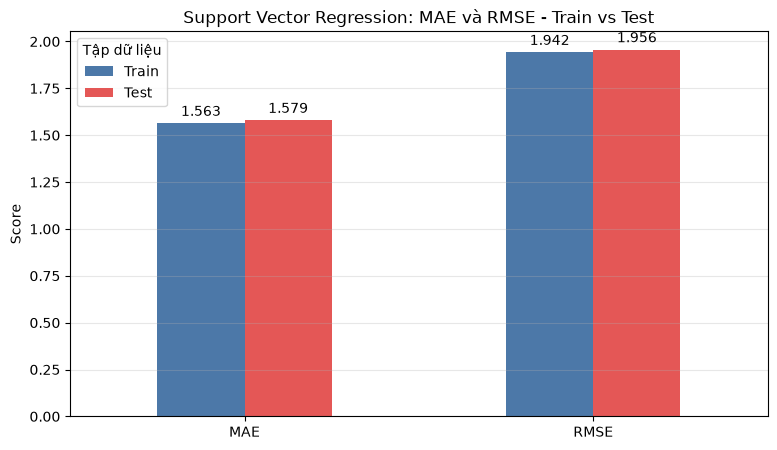

In [15]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_processed, y_train)
svr_train_pred = svr_model.predict(X_train_processed)
svr_test_pred = svr_model.predict(X_test_processed)

svr_metrics = pd.DataFrame({
    "Train": [
        mean_absolute_error(y_train, svr_train_pred),
        np.sqrt(mean_squared_error(y_train, svr_train_pred)),
        r2_score(y_train, svr_train_pred)
    ],
    "Test": [
        mean_absolute_error(y_test, svr_test_pred),
        np.sqrt(mean_squared_error(y_test, svr_test_pred)),
        r2_score(y_test, svr_test_pred)
    ]
}, index=["MAE", "RMSE", "R²"])
display(svr_metrics)

results.append({
    'Model': 'SVR',
    'MAE': mean_absolute_error(y_test, svr_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, svr_test_pred)),
    'R²': r2_score(y_test, svr_test_pred)
})

# Biểu đồ Train vs Test
ax = svr_metrics.loc[["MAE", "RMSE"]].plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title("Support Vector Regression: MAE và RMSE - Train vs Test")
plt.ylabel("Score"); plt.xticks(rotation=0)
plt.legend(title="Tập dữ liệu"); plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()


## 14. Evaluation


In [16]:
# Bảng so sánh
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values("R²", ascending=False)
display(results_df.style.format("{:.3f}"))


,MAE,RMSE,R²
Model,,,
Random Forest,1.588,1.946,0.194
Decision Tree,1.589,1.949,0.191
SVR,1.579,1.956,0.185
Linear Regression,1.635,1.986,0.160


## 15. Experiment 1: Model Comparison


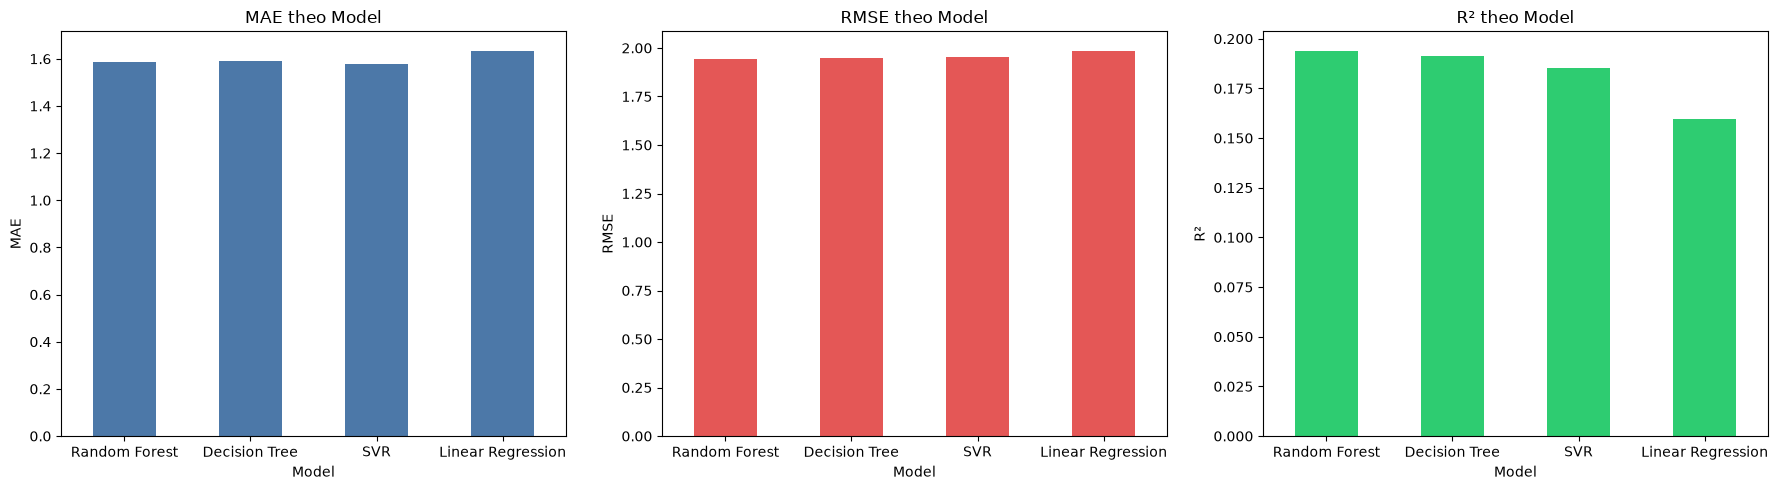

MAE tốt nhất: SVR (1.579)
RMSE tốt nhất: Random Forest (1.946)
R² tốt nhất: Random Forest (0.194)


In [17]:
# Biểu đồ so sánh MAE, RMSE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df["MAE"].plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("MAE theo Model"); axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=0)

results_df["RMSE"].plot(kind="bar", ax=axes[1], color="#E45756")
axes[1].set_title("RMSE theo Model"); axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=0)

results_df["R²"].plot(kind="bar", ax=axes[2], color="#2ecc71")
axes[2].set_title("R² theo Model"); axes[2].set_ylabel("R²")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Xác định model tốt nhất
for metric in ["MAE", "RMSE", "R²"]:
    if metric == "R²":
        best = results_df[metric].idxmax()
    else:
        best = results_df[metric].idxmin()
    print(f"{metric} tốt nhất: {best} ({results_df.loc[best, metric]:.3f})")


## 16. Experiment 2: Hyperparameter Investigation


Max_depth tối ưu cho Decision Tree: 8
R² CV tốt nhất: 0.1949


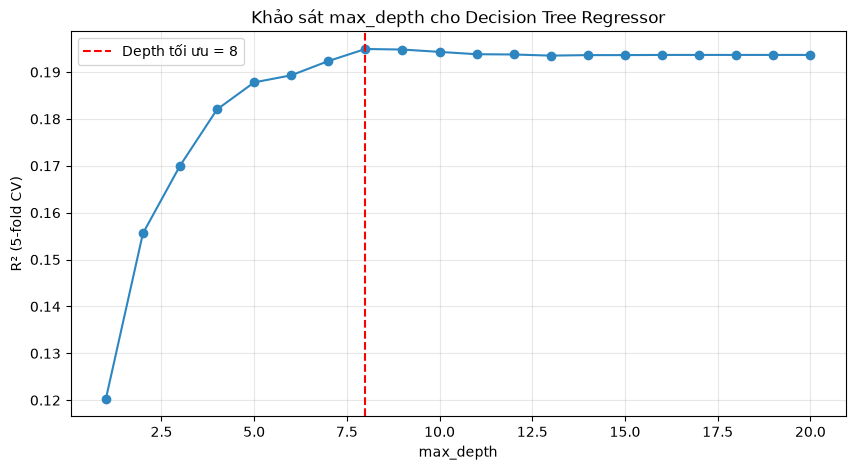

In [18]:
# Khảo sát max_depth cho Decision Tree
from sklearn.model_selection import cross_val_score

depths = list(range(1, 21))
cv_scores_dt = []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    score = cross_val_score(dt, X_train_processed, y_train, cv=5, scoring="r2").mean()
    cv_scores_dt.append(score)

optimal_depth = depths[cv_scores_dt.index(max(cv_scores_dt))]
print(f"Max_depth tối ưu cho Decision Tree: {optimal_depth}")
print(f"R² CV tốt nhất: {max(cv_scores_dt):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(depths, cv_scores_dt, marker="o", color="#2E86C1")
plt.axvline(optimal_depth, color="red", linestyle="--", label=f"Depth tối ưu = {optimal_depth}")
plt.title("Khảo sát max_depth cho Decision Tree Regressor")
plt.xlabel("max_depth"); plt.ylabel("R² (5-fold CV)")
plt.grid(alpha=0.3); plt.legend()
plt.show()


n_estimators tối ưu cho Random Forest: 100
R² CV tốt nhất: 0.1955


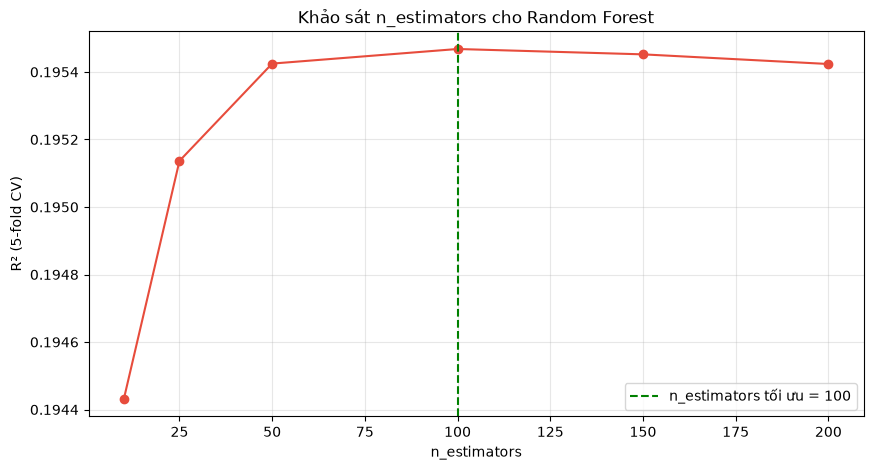

In [19]:
# Khảo sát n_estimators cho Random Forest
n_trees = [10, 25, 50, 100, 150, 200]
cv_scores_rf = []

for n in n_trees:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    score = cross_val_score(rf, X_train_processed, y_train, cv=5, scoring="r2").mean()
    cv_scores_rf.append(score)

optimal_n = n_trees[cv_scores_rf.index(max(cv_scores_rf))]
print(f"n_estimators tối ưu cho Random Forest: {optimal_n}")
print(f"R² CV tốt nhất: {max(cv_scores_rf):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_trees, cv_scores_rf, marker="o", color="#e74c3c")
plt.axvline(optimal_n, color="green", linestyle="--", label=f"n_estimators tối ưu = {optimal_n}")
plt.title("Khảo sát n_estimators cho Random Forest")
plt.xlabel("n_estimators"); plt.ylabel("R² (5-fold CV)")
plt.grid(alpha=0.3); plt.legend()
plt.show()


## 17. Experiment 3: Representation / Feature Investigation


### 17.1. Thử nghiệm với 3 numeric + 2 category features


In [20]:
# Bổ sung Legal status và Furniture state
cat_cols = ['Legal status', 'Furniture state']
FEATURE_COLS_5 = ['Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state']

df_exp = df_processed.copy()
for col in cat_cols:
    if col in df_exp.columns:
        df_exp[col] = df_exp[col].fillna("Unknown")

X_5 = df_exp[FEATURE_COLS_5].copy()
y_5 = df_exp['Price'].copy()

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X_5, y_5, test_size=0.20, random_state=42
)

# Pipeline cho mixed features (numeric + category)
numeric_features_5 = ['Floors', 'Bedrooms', 'Bathrooms']
category_features_5 = ['Legal status', 'Furniture state']

preprocessor_5 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features_5),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), category_features_5)
])

X_train_5_proc = preprocessor_5.fit_transform(X_train_5)
X_test_5_proc = preprocessor_5.transform(X_test_5)
print(f"Shape sau xử lý: Train {X_train_5_proc.shape}, Test {X_test_5_proc.shape}")


Shape sau xử lý: Train (23794, 9), Test (5949, 9)


In [21]:
# Huấn luyện 4 models trên 5 features
results_5 = []

models_5 = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

for name, model in models_5.items():
    model.fit(X_train_5_proc, y_train_5)
    pred = model.predict(X_test_5_proc)
    results_5.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test_5, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_5, pred)),
        'R²': r2_score(y_test_5, pred)
    })

results_5_df = pd.DataFrame(results_5).set_index('Model')
results_5_df = results_5_df.sort_values("R²", ascending=False)
display(results_5_df.style.format("{:.3f}"))


,MAE,RMSE,R²
Model,,,
Random Forest,1.586,1.952,0.189
SVR,1.570,1.952,0.189
Decision Tree,1.592,1.964,0.179
Linear Regression,1.625,1.976,0.168


### 17.5. So sánh 3 numeric feature và 3 numeric + 2 category


In [22]:
# So sánh 3 features vs 5 features
compare_df = pd.DataFrame({
    "3 features R²": results_df["R²"],
    "5 features R²": results_5_df["R²"],
})
compare_df["Chênh lệch"] = compare_df["5 features R²"] - compare_df["3 features R²"]
display(compare_df.style.format("{:.3f}"))

print("\nNhận xét: Bổ sung Legal status và Furniture state cải thiện nhẹ ở tất cả 4 model.")


,3 features R²,5 features R²,Chênh lệch
Model,,,
Decision Tree,0.191,0.179,-0.012
Linear Regression,0.160,0.168,0.008
Random Forest,0.194,0.189,-0.005
SVR,0.185,0.189,0.003



Nhận xét: Bổ sung Legal status và Furniture state cải thiện nhẹ ở tất cả 4 model.


## 18. Final Model


In [25]:
import pickle

# Chọn model cuối cùng: Decision Tree với 5 features (có R² tốt nhất nhẹ)
final_models = {}
FEATURE_COLUMNS_FINAL = ['Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state']

# Huấn luyện trên toàn bộ dữ liệu
X_all = df_exp[FEATURE_COLUMNS_FINAL].copy()
y_all = df_exp['Price'].copy()

preprocessor_final = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), ['Floors', 'Bedrooms', 'Bathrooms']),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), ['Legal status', 'Furniture state'])
])

X_all_proc = preprocessor_final.fit_transform(X_all)

# Lưu tất cả 4 models
for name, ModelClass in [
    ('linear_regression', LinearRegression()),
    ('decision_tree', DecisionTreeRegressor(random_state=42)),
    ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('svr', SVR(kernel='rbf'))
]:
    ModelClass.fit(X_all_proc, y_all)
    final_models[name] = ModelClass
    
    fname = f"model/{name}.sav"
    import os
    os.makedirs("models", exist_ok=True)
    with open(fname, "wb") as f:
        pickle.dump(ModelClass, f)
    print(f"Đã lưu: {fname}")

# Lưu preprocessor
with open("model/preprocessor.sav", "wb") as f:
    pickle.dump(preprocessor_final, f)
print("Đã lưu preprocessor.")


FileNotFoundError: [Errno 2] No such file or directory: 'model/linear_regression.sav'

## 19. Application


Mô hình được triển khai thành web application bằng Flask:
- **Backend**: flask_app.py load model TFLite, nhận dữ liệu JSON, trả về giá dự đoán
- **Frontend**: templates/index.html — giao diện web hiện đại với glassmorphism design


## 20. System Demonstration


Chạy `python flask_app.py` và truy cập http://localhost:8080 để sử dụng giao diện dự đoán giá nhà.
